In [3]:
import pandas as pd
import os
from tqdm import tqdm

# Input paths
SOURCE_CSV = "/home/yuyao/methane_train/csvs/merged_file.csv" 
OUT_CSV = "./CM_L89_L2SR_gee.csv"

# Directory mapping
DIRS = {
    "t0": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_L2SR_by_gee",
    "m7": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_-7_L2SR_by_gee",
    "hist": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee"
}

def build_file_map(directory):
    """Creates a mapping of plume_id -> [list of full paths]"""
    file_map = {}
    if not os.path.exists(directory):
        print(f"Warning: Directory not found: {directory}")
        return file_map
    
    # os.scandir is the fastest way to list files
    with os.scandir(directory) as it:
        for entry in it:
            if entry.is_file() and entry.name.endswith(".tif"):
                # Extract plume_id: assumes plume_id is the string before the first underscore 
                # or based on your example 'tan...-A'
                if "_minus90" in entry.name:
                    pid = entry.name.split('_l89')[0].split('_minus90')[0]
                elif "_minus360" in entry.name:
                    pid = entry.name.split('_l89')[0].split('_minus360')[0]
                else:
                    pid = entry.name.split('_l89')[0]
                # pid = entry.name.split('_l89')[0].split('_minus90')[0] or entry.name.split('_l89')[0].split('_minus360')[0]
                if pid not in file_map:
                    file_map[pid] = []
                file_map[pid].append(entry.path)
    return file_map

# 1. Pre-scan all directories (This is the speed secret)
print("Scanning directories...")
map_t0 = build_file_map(DIRS["t0"])
map_m7 = build_file_map(DIRS["m7"])
map_hist = build_file_map(DIRS["hist"])

# 2. Load source and match in memory
df = pd.read_csv(SOURCE_CSV)
new_data = []

print("Matching plumes...")
for pid in tqdm(df['plume_id'].unique()):
    # Lookup t0
    path0 = map_t0.get(pid, [""])[0]
    
    # Lookup m7
    path7 = map_m7.get(pid, [""])[0]
    
    # Lookup hist (90 and 360)
    hist_files = map_hist.get(pid, [])
    path90 = ""
    path360 = ""
    
    for f in hist_files:
        print(f)
        # exit()
        if "minus90_" in f:
            path90 = f
        elif "minus360_" in f:
            # Assumes the other file in the 90360 folder is the 360 one
            path360 = f

    new_data.append({
        "plume_id": pid,
        "l89_path": path0,
        "l89_-7_path": path7,
        "l89_pre_path": path90,
        "l89_pre_pre_path": path360,
        "std_ok": 0
    })

# 3. Save
out_df = pd.DataFrame(new_data)
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
out_df.to_csv(OUT_CSV, index=False)

print(f"Done. Successfully matched {len(out_df)} plumes.")

Scanning directories...
Matching plumes...


100%|██████████| 24470/24470 [00:00<00:00, 546798.47it/s]

/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-D_minus360_l89_sr_LANDSAT_8_20181028T172713Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-D_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-F_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-F_minus360_l89_sr_LANDSAT_8_20181028T172713Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-G_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_

In [11]:
df = pd.read_csv("./CM_L89_L2SR_gee.csv")
df.dropna(subset=['l89_path', 'l89_-7_path', 'l89_pre_path', 'l89_pre_pre_path'], inplace=True)
print(len(df))
df.to_csv("./CM_L89_L2SR_gee.csv", index=False)

2623


样本 GAO20240611t204534p0000-C:
  图像尺寸: 520x521
  CSV 目标点像素位置: (x=259.00, y=260.00)
  偏移中心点: (dx=3.00, dy=4.00)


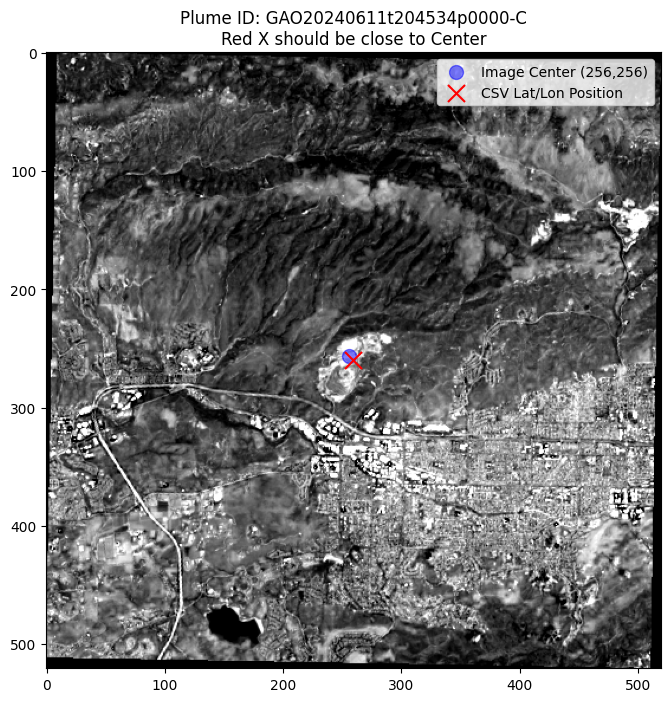

样本 tan20251023t052445c08s4001-A:
  图像尺寸: 517x518
  CSV 目标点像素位置: (x=257.00, y=259.00)
  偏移中心点: (dx=1.00, dy=3.00)


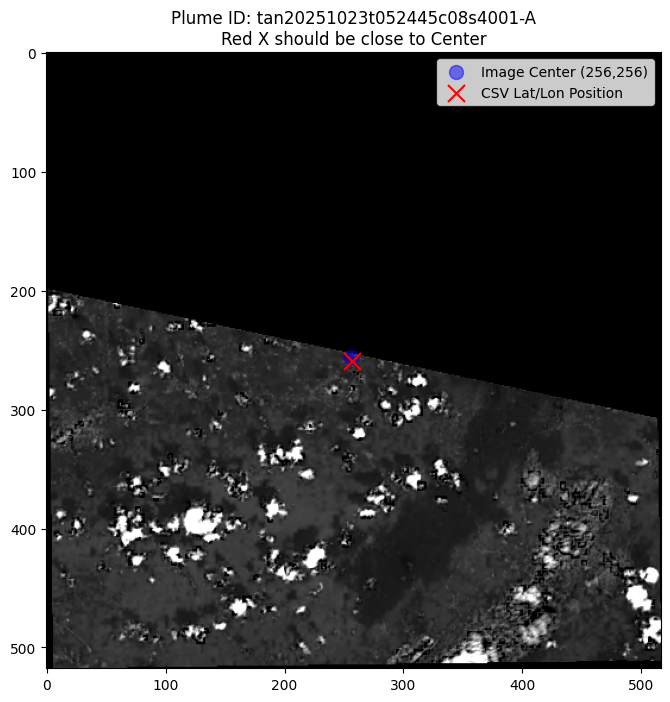

样本 tan20241026t103729c00s4001-H:
  图像尺寸: 526x526
  CSV 目标点像素位置: (x=262.00, y=263.00)
  偏移中心点: (dx=6.00, dy=7.00)


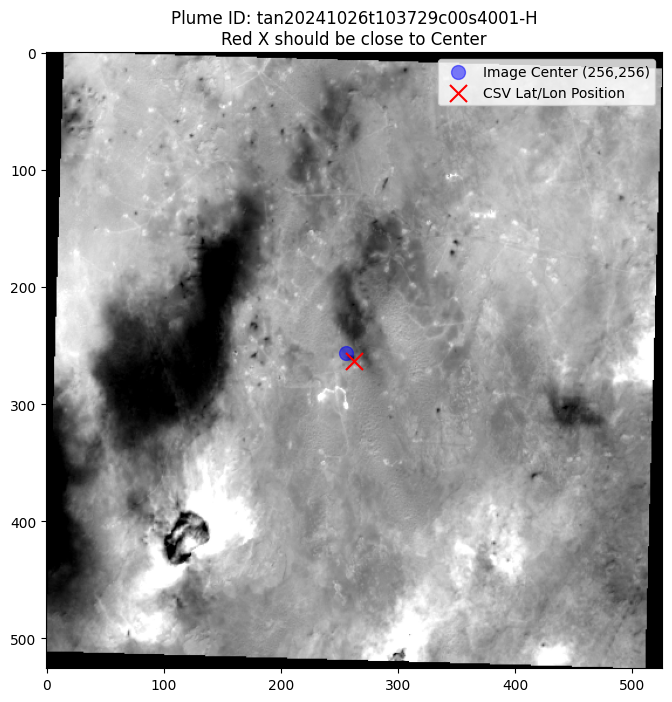

样本 emi20241219t080409p05003-C:
  图像尺寸: 517x516
  CSV 目标点像素位置: (x=258.00, y=258.00)
  偏移中心点: (dx=2.00, dy=2.00)


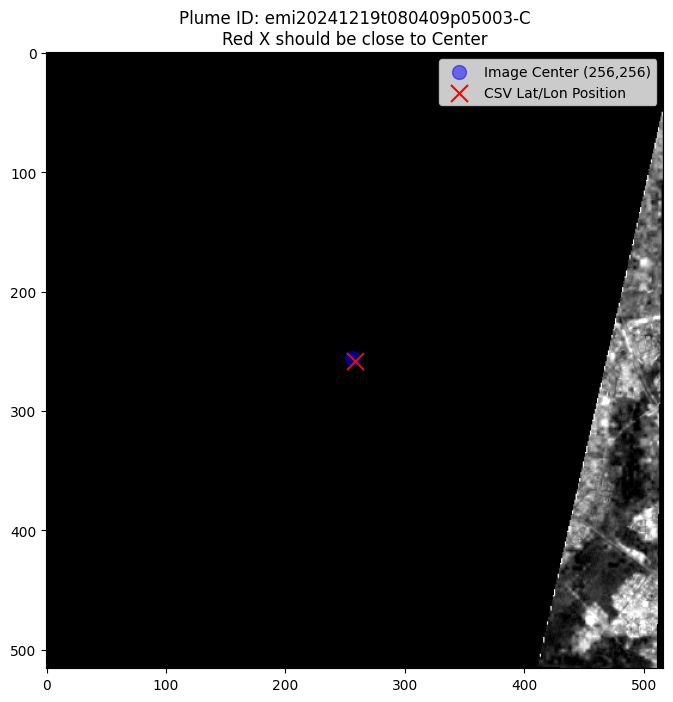

样本 tan20250510t033900c00s4001-E:
  图像尺寸: 525x526
  CSV 目标点像素位置: (x=261.00, y=262.00)
  偏移中心点: (dx=5.00, dy=6.00)


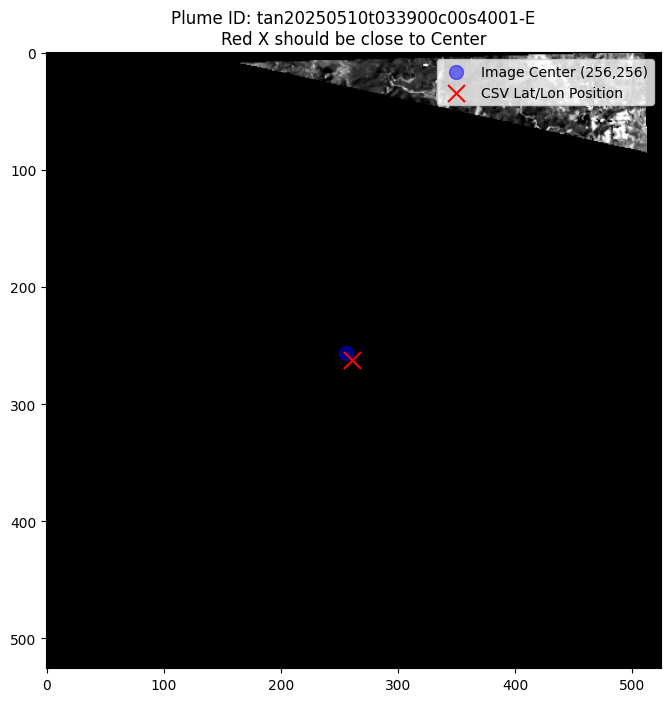

样本 emi20231226t065450p05004-A:
  图像尺寸: 513x514
  CSV 目标点像素位置: (x=255.00, y=257.00)
  偏移中心点: (dx=-1.00, dy=1.00)


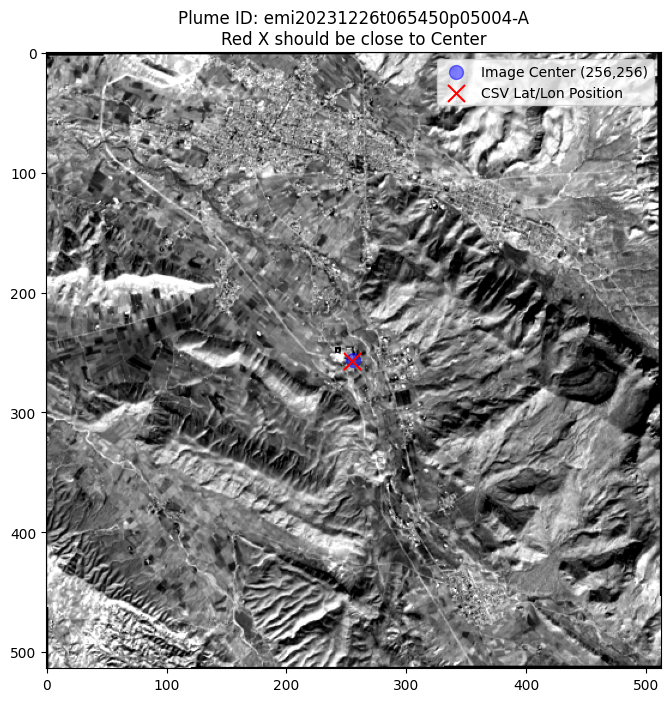

样本 GAO20240513t154638p0000-A:
  图像尺寸: 516x516
  CSV 目标点像素位置: (x=257.00, y=258.00)
  偏移中心点: (dx=1.00, dy=2.00)


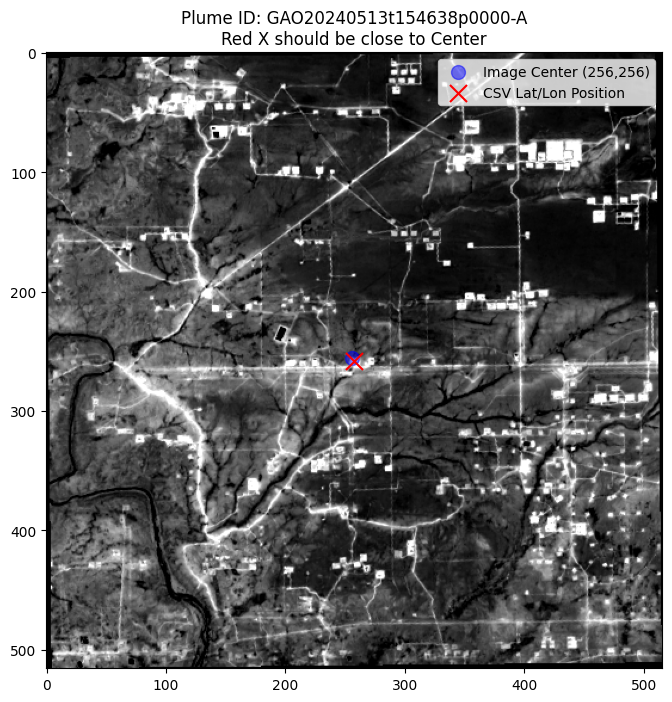

样本 tan20241203t073043c00s4001-B:
  图像尺寸: 528x530
  CSV 目标点像素位置: (x=263.00, y=265.00)
  偏移中心点: (dx=7.00, dy=9.00)


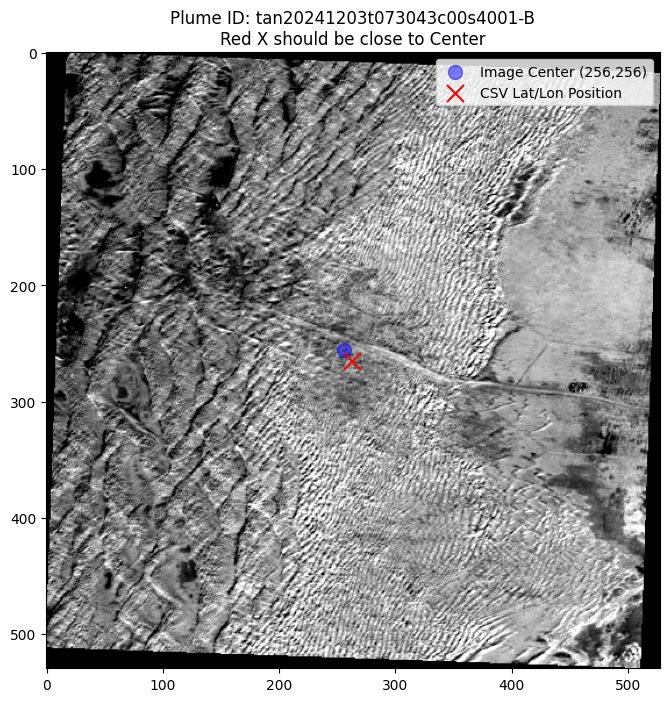

In [3]:
import pandas as pd
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer

# =========================
# 配置
# =========================
# 使用包含下载后本地路径的 CSV
L89_CSV = '/data2/yuyao/methane_emission/preprocess_dataset_L89/CM_L89_L2SR_std512.csv'

def verify_downloaded_chips(num_samples=5):
    df = pd.read_csv(L89_CSV)
    # 筛选下载成功的样本 (假设列名是 l89_path)
    df = df[df['l89_path'].notna()].sample(num_samples)

    for _, row in df.iterrows():
        pid = row['plume_id']
        tif_path = row['l89_path']
        lat = row['plume_latitude']
        lon = row['plume_longitude']

        if not os.path.exists(tif_path):
            print(f"文件不存在: {tif_path}")
            continue

        with rasterio.open(tif_path) as src:
            # 1. 将 CSV 经纬度转为该图的投影坐标 (UTM)
            transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
            target_x, target_y = transformer.transform(lon, lat)

            # 2. 计算该坐标在图中的像素行列号
            # row_idx (y), col_idx (x)
            py, px = src.index(target_x, target_y)

            # 3. 读取第一波段用于显示 (通常是 B1)
            data = src.read(1)
            
            # 简单的显示拉伸
            vmin, vmax = np.percentile(data[data > 0], [2, 98])
            data_scaled = np.clip(data, vmin, vmax)

            print(f"样本 {pid}:")
            print(f"  图像尺寸: {src.width}x{src.height}")
            print(f"  CSV 目标点像素位置: (x={px:.2f}, y={py:.2f})")
            print(f"  偏移中心点: (dx={px-256:.2f}, dy={py-256:.2f})")

            # 绘图
            plt.figure(figsize=(8, 8))
            plt.imshow(data_scaled, cmap='gray')
            
            # 画出图像的几何中心 (蓝色)
            plt.scatter(256, 256, color='blue', marker='o', s=100, label='Image Center (256,256)', alpha=0.5)
            # 画出 CSV 记录的实际经纬度位置 (红色)
            plt.scatter(px, py, color='red', marker='x', s=150, label='CSV Lat/Lon Position')
            
            plt.title(f"Plume ID: {pid}\nRed X should be close to Center")
            plt.legend()
            plt.show()

if __name__ == "__main__":
    verify_downloaded_chips(num_samples=8)

In [11]:
ds1=pd.read_csv('./CM_L89_L2SR_gee.csv')
ds2=pd.read_csv("/home/yuyao/methane_train/csvs/merged_file.csv")
cols=["plume_id","plume_latitude", "plume_longitude", "datetime"]
ds2=ds2[cols].drop_duplicates(subset=["plume_id"])
ds=ds1.merge(ds2,how="left",on="plume_id")
missing=ds["plume_latitude"].isna().sum()
print("missing: ", missing)
ds.to_csv("./CM_L89_L2SR_gee.csv")

missing:  0


In [1]:
# crop to 512x512 with NaN handling
import os
import threading
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import contextlib

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm
from functools import lru_cache

# =========================
# Config
# =========================
CM_CSV  = "./CM_L89_L2SR_gee.csv"
OUT_CSV = "./CM_L89_L2SR_std512.csv"
OUT_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/L89_-790360_512std"

WINDOW_SIZE = 512
MAX_WORKERS = 12
REQUIRE_T0 = True
REQUIRE_M7 = True 

def debug(msg: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}][pid:{os.getpid()}][tid:{threading.get_ident()}] {msg}", flush=True)

# =========================
# Core Processing Logic
# =========================

@lru_cache(maxsize=128)
def get_transformer(src_crs):
    return Transformer.from_crs("EPSG:4326", src_crs, always_xy=True)

def process_chip_centered(in_path, out_path, lat, lon):
    """
    通过经纬度定位中心，读取并保存 512x512 图像，保留地理信息。
    """
    if not (isinstance(in_path, str) and os.path.exists(in_path)):
        return False, "missing"

    try:
        with rasterio.open(in_path) as src:
            # 1. 坐标转换: Lat/Lon -> Image Projection (UTM)
            transformer = get_transformer(src.crs)
            target_x, target_y = transformer.transform(lon, lat)

            # 2. 获取目标点在原图中的像素行列号 (浮点数)
            row_f, col_f = src.index(target_x, target_y)
            
            # 3. 定义 512x512 Window (以目标点为中心)
            # 这里的 Window 会自动处理亚像素偏移的整数化
            win = Window(
                col_off=int(round(col_f - WINDOW_SIZE / 2)),
                row_off=int(round(row_f - WINDOW_SIZE / 2)),
                width=WINDOW_SIZE,
                height=WINDOW_SIZE
            )

            # 4. 读取数据 (boundless=True 会自动处理超出边界的情况)
            # fill_value=0 先读取，后面统一转 NaN
            arr = src.read(window=win, boundless=True, fill_value=0).astype(np.float32)
            
            # 5. 计算新图像的 Transform (为了后续 Mask 对齐)
            # 这个 new_transform 确保了该 Chip 的地理参考依然正确
            new_transform = src.window_transform(win)

            # 6. NaN 处理: 识别 Landsat NoData (全波段为0)
            nodata_mask = (np.sum(arr, axis=0) == 0)
            for b in range(arr.shape[0]):
                arr[b, nodata_mask] = np.nan

            # 7. 写入磁盘 (保留 CRS 和 更新后的 Transform)
            profile = src.profile.copy()
            profile.update({
                "driver": "GTiff",
                "height": WINDOW_SIZE,
                "width": WINDOW_SIZE,
                "count": src.count,
                "dtype": "float32",
                "transform": new_transform,
                "crs": src.crs,
                "compress": "deflate",
                "predictor": 2,
                "tiled": True,
                "nodata": np.nan # 显式标记 NaN 为 NoData
            })

            os.makedirs(os.path.dirname(out_path), exist_ok=True)
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(arr)

            return True, "success"
            
    except Exception as e:
        return False, str(e)

# =========================
# Worker Wrapper
# =========================
def process_one_row_l89(row: dict):
    plume_id = str(row.get("plume_id", "")).strip()
    lat = row.get("plume_latitude")
    lon = row.get("plume_longitude")
    
    if pd.isna(lat) or pd.isna(lon):
        return plume_id, {"std_ok": 0, "bug": "invalid_lat_lon"}

    # 定义我们要处理的列名和对应的输出文件名
    # 这样我们可以显式控制 tag，避免空字符串
    tasks = [
        ("l89_path", "l89_0_std_512.tif", "t0"),
        ("l89_-7_path", "l89_-7_std_512.tif", "m7"),
        ("l89_pre_path", "l89_-90_std_512.tif", "m90"),
        ("l89_pre_pre_path", "l89_-360_std_512.tif", "m360")
    ]

    results_row = {"plume_id": plume_id}
    bug_list = []
    
    status_map = {}

    for col_name, fname, tag in tasks:
        raw_val = row.get(col_name, "")
        # 处理可能的重复列导致的 Series 问题
        if isinstance(raw_val, pd.Series):
            raw_val = raw_val.iloc[0]
            
        in_p = str(raw_val) if pd.notna(raw_val) else ""
        out_p = os.path.join(OUT_ROOT, plume_id, fname)
        
        success = 0
        if in_p and os.path.exists(in_p):
            ok, msg = process_chip_centered(in_p, out_p, lat, lon)
            if ok:
                success = 1
            else:
                bug_list.append(f"{tag}:{msg}")
        
        # 统一存储路径和状态
        status_map[tag] = success
        # 如果需要把路径写回 CSV，可以取消下面注释
        # results_row[f"{tag}_std_512_path"] = out_p if success else ""

    # 逻辑判断
    t0_ok = status_map.get("t0", 0)
    m7_ok = status_map.get("m7", 0)
    
    # 根据你的 Config 要求判断是否合格
    is_std_ok = 1
    if REQUIRE_T0 and not t0_ok: is_std_ok = 0
    if REQUIRE_M7 and not m7_ok: is_std_ok = 0

    results_row["std_ok"] = is_std_ok
    results_row["bug"] = "; ".join(bug_list)
    
    # 为了保持 DataFrame 列对齐，把 has_xxx 状态也传回去
    for tag, val in status_map.items():
        results_row[f"has_{tag}"] = val

    return plume_id, results_row

# =========================
# Main
# =========================
if __name__ == "__main__":
    df = pd.read_csv(CM_CSV)
    
    for c in ["std_ok", "bug"]:
        if c not in df.columns: df[c] = 0

    work_df = df[df["std_ok"] != 1].copy()
    debug(f"Tasks to process: {len(work_df)}")
    
    all_results = [] # 优化 2: 收集结果
    
    with ThreadPoolExecutor(max_workers=24) as ex: # 优化 3: 适当增加 worker
        futs = [ex.submit(process_one_row_l89, r.to_dict()) for _, r in work_df.iterrows()]
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Standardizing L89"):
            pid, upd = fut.result()
            all_results.append(upd)

    # 优化 4: 一次性更新 DataFrame
    if all_results:
        res_df = pd.DataFrame(all_results)
        # 将 plume_id 设为索引方便合并
        df.set_index('plume_id', inplace=True)
        res_df.set_index('plume_id', inplace=True)
        
        # 更新原 df
        df.update(res_df)
        df.reset_index(inplace=True)

    df.to_csv(OUT_CSV, index=False)
    debug("Preprocessing Complete.")

[2026-01-28 16:36:00][pid:4153492][tid:135676582704192] Tasks to process: 2623


Standardizing L89: 100%|██████████| 2623/2623 [29:39<00:00,  1.47it/s]  


[2026-01-28 17:05:41][pid:4153492][tid:135676582704192] Preprocessing Complete.


/tmp/ipykernel_4153492/3388674814.py:197: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['' '' '' ... '' '' '']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(res_df)


In [2]:
import pandas as pd
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm

# =========================
# 配置 (根据你的环境修改)
# =========================
# 包含 plume_id, path_t0 (Landsat路径), latitude, longitude 的 CSV
# SOURCE_CSV = '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'
L89_CSV='./CM_L89_L2SR_std512.csv'

# 原始高分辨率航空掩膜的存储根目录
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

# 目标输出目录：生成的 30m 512x512 对齐掩膜
OUT_MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'

TARGET_RES = 30  # Landsat 8/9 原生分辨率 (米)
TARGET_SIZE = 512

# =========================
# 核心处理函数
# =========================

def process_l89_mask(plume_id, center_lat, center_lon, ref_tif_path):
    """
    通过读取参考卫星图 (ref_tif_path) 的 CRS，将航空掩膜重投影并对齐。
    """
    # 定义输出路径
    dst_path = os.path.join(OUT_MASK_ROOT, plume_id, 'mask_30m_512.tif')
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    # 定义输入掩膜路径
    input_tif = os.path.join(BASE_AIRBORNE_DIR, plume_id, 'plume.tif')

    # 检查必要文件是否存在
    if not os.path.exists(input_tif):
        return False, f"Source mask missing: {input_tif}"
    if not os.path.exists(ref_tif_path):
        return False, f"Reference Landsat missing: {ref_tif_path}"

    try:
        # 1. 动态获取 Landsat 卫星图的 CRS (如 EPSG:32613)
        with rasterio.open(ref_tif_path) as ref:
            target_crs = ref.crs
            # 如果参考图本身就是 512x512，我们可以直接复用它的 transform
            ref_transform = ref.transform
            ref_height, ref_width = ref.height, ref.width

        with rasterio.open(input_tif) as src:
            if src.height == 0 or src.width == 0:
                return False, "Empty source TIFF"

            # 2. 坐标转换：将 CSV 里的经纬度转为目标卫星图的投影坐标
            transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            # 3. 网格吸附 (Grid Snapping)
            # 确保 Mask 的像素中心与卫星图像素点完全重合
            center_x = round(center_x / TARGET_RES) * TARGET_RES
            center_y = round(center_y / TARGET_RES) * TARGET_RES

            # 4. 计算 512x512 窗口的左上角坐标
            top_left_x = center_x - (TARGET_SIZE // 2) * TARGET_RES
            top_left_y = center_y + (TARGET_SIZE // 2) * TARGET_RES
            
            # 构造新的仿射变换矩阵
            new_transform = Affine(TARGET_RES, 0, top_left_x, 0, -TARGET_RES, top_left_y)
            
            # 5. 准备输出阵列
            out_mask = np.zeros((1, TARGET_SIZE, TARGET_SIZE), dtype='uint8')

            # 6. 执行重投影 (使用最近邻插值保持标签纯净)
            reproject(
                source=rasterio.band(src, 1),
                destination=out_mask[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=target_crs, # 关键：投影到卫星图的坐标系
                resampling=Resampling.nearest
            )

            # 7. 写入磁盘，保留所有地理信息
            profile = src.profile.copy()
            profile.update(
                driver='GTiff',
                transform=new_transform,
                crs=target_crs,
                width=TARGET_SIZE,
                height=TARGET_SIZE,
                count=1,
                dtype='uint8',
                compress='lzw',
                nodata=0
            )

            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(out_mask)
            
            return True, "Success"

    except Exception as e:
        return False, str(e)

# =========================
# 主程序
# =========================

if __name__ == "__main__":
    print(f"Loading source data from {L89_CSV}...")
    df = pd.read_csv(L89_CSV)
    
    # 确保 CSV 中包含必要的路径列，如果没有 path_t0 请根据实际列名修改
    # 假设你的列名叫 'path_t0'
    work_df = df[df['l89_path'].notna()].copy()
    
    print(f"Total plumes to process: {len(work_df)}")

    results = []
    for index, row in tqdm(work_df.iterrows(), total=len(work_df)):
        pid = row['plume_id']
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        ref_path = row['l89_path'] # 卫星图路径
        
        # 排除已知的异常数据
        if pid == 'GAO20210515t145818p0000-1':
            continue
            
        success, msg = process_l89_mask(pid, lat, lon, ref_path)
        if not success:
            results.append({"plume_id": pid, "error": msg})

    # 输出错误日志
    if results:
        error_df = pd.DataFrame(results)
        error_df.to_csv('mask_gen_errors.csv', index=False)
        print(f"\nDone. Errors encountered: {len(results)}. See mask_gen_errors.csv")
    else:
        print("\nDone. All masks generated and aligned successfully.")

Loading source data from ./CM_L89_L2SR_std512.csv...
Total plumes to process: 2623


  0%|          | 0/2623 [00:00<?, ?it/s]

100%|██████████| 2623/2623 [00:03<00:00, 755.35it/s]


Done. Errors encountered: 2623. See mask_gen_errors.csv


In [ ]:
import pandas as pd
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize

# =========================
# 路径配置
# =========================
CSV_PATH = './CM_L89_L2SR_std512.csv' 
MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

def load_and_preprocess_landsat(path):
    if not os.path.exists(path):
        return None
    try:
        with rasterio.open(path) as src:
            data = src.read(1).astype(float)
            # 排除 Landsat 常用的填充值 (0 或 NaN)
            valid_mask = (data > 0) & (~np.isnan(data))
            if not np.any(valid_mask):
                return np.zeros_like(data)
            
            # 鲁棒性拉伸：解决 L89 图像全白/全黑问题
            vmin, vmax = np.percentile(data[valid_mask], [2, 98])
            data_clipped = np.clip(data, vmin, vmax)
            return (data_clipped - vmin) / (vmax - vmin + 1e-6)
    except:
        return None

def get_mask_data(path):
    if os.path.exists(path):
        with rasterio.open(path) as src:
            return src.read(1)
    return None

# 读取数据
df = pd.read_csv(CSV_PATH)
# 只要处理成功的行进行检查
df_check = df[df['std_ok'].astype(str) == '1'].head(10) 

for index, row in df_check.iterrows():
    pid = row['plume_id']
    # 使用你最新的标准 512 路径列名
    l89_t0_path = row['l89_0_std_512'] 
    
    airborne_mask_path = os.path.join(BASE_AIRBORNE_DIR, pid, 'plume.tif')
    # 我们新生成的 30m 掩膜
    resized_mask_path = os.path.join(MASK_ROOT, pid, 'mask_30m_512.tif')

    img_airborne = get_mask_data(airborne_mask_path)
    img_resized = get_mask_data(resized_mask_path)
    img_landsat = load_and_preprocess_landsat(l89_t0_path)

    if img_landsat is None or img_resized is None:
        print(f"Skipping {pid}: Data missing. Mask: {os.path.exists(resized_mask_path)}")
        continue

    print(f"Checking {pid} | Landsat: {img_landsat.shape} | Mask: {img_resized.shape}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. 原始航空掩膜 (作为真值参考)
    axes[0].imshow(img_airborne if img_airborne is not None else np.zeros((10,10)), cmap='viridis')
    axes[0].set_title(f"Original Airborne Mask\n(High Res)")

    # 2. Landsat 30m 图像 (确认底图没问题)
    axes[1].imshow(img_landsat, cmap='gray')
    axes[1].set_title(f"Standardized Landsat 30m\n(Crop 512x512)")
    axes[1].axhline(256, color='white', linestyle='--', alpha=0.3)
    axes[1].axvline(256, color='white', linestyle='--', alpha=0.3)

    # 3. 核心验收：叠加显示
    # 图3: 叠加显示 (优化可见性)
    axes[2].imshow(img_landsat, cmap='gray')
    
    if img_resized is not None:
        # 1. 强制将掩膜转为 bool 或明显的二值（只要大于0就显示）
        # 这样即使像素值很小（如 23），也会以最亮的颜色显示
        binary_mask = (img_resized > 0).astype(float)
        
        # 2. 只有在有内容的地方才显示覆盖层
        masked_plume = np.ma.masked_where(binary_mask == 0, binary_mask)
        
        # 3. 使用 'spring' 或 'bright_red' 这种高对比度颜色
        # 增加 alpha 到 0.8 确保看得到
        axes[2].imshow(masked_plume, cmap='spring', alpha=0.8) 
        
        # 4. 打印一个计数，让我们心理有数
        num_pixels = np.count_nonzero(img_resized)
        axes[2].set_title(f"Overlay: {num_pixels} px detected")
    else:
        axes[2].set_title("Resized Mask Missing")
    print(f"Mask values - Max: {img_resized.max()}, Min: {img_resized.min()}, Unique: {np.unique(img_resized)}")

    plt.tight_layout()
    plt.show()

In [8]:
import pandas as pd
import os

# Paths
CSV_PATH = "./CM_L89_L2SR_std512.csv"
MASK_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512"

df = pd.read_csv(CSV_PATH)

def get_mask_path(pid):
    # This matches the structure: /MASK_ROOT/plume_id/mask_30m_512.tif
    path = os.path.join(MASK_ROOT, str(pid), 'mask_30m_512.tif')
    return path if os.path.exists(path) else None

print("Updating mask paths...")
df['mask_path'] = df['plume_id'].apply(get_mask_path)

# Check for missing masks
missing_count = df['mask_path'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} plumes do not have a mask file in {MASK_ROOT}")

df.to_csv(CSV_PATH, index=False)
print("CSV updated successfully.")

Updating mask paths...
CSV updated successfully.


In [3]:
import tifffile
import numpy as np
import pandas as pd

df = pd.read_csv("./CM_L89_L2SR_std512.csv")
sample_path = df['l89_0_std_512'].iloc[0]
img = tifffile.imread(sample_path)

print(f"Min value: {np.nanmin(img)}")
print(f"Max value: {np.nanmax(img)}")
print(f"Number of NaNs: {np.isnan(img).sum()}")
print(f"Number of Zeros: {(img == 0).sum()}")

Min value: 0.0
Max value: 65454.0
Number of NaNs: 46140
Number of Zeros: 1932189


In [8]:
import pandas as pd
import os

# Paths
MANIFEST_PATH = "./CM_L89_L2SR_std512.csv"
METADATA_PATH = "/home/yuyao/methane_train/csvs/merged_file.csv"

# 1. Load the files
print("Loading data...")
manifest_df = pd.read_csv(MANIFEST_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

# 2. Extract only necessary columns from metadata to avoid clutter
# We use plume_id as the key and datetime as the value to add
metadata_subset = metadata_df[['plume_id', 'datetime', "plume_latitude", "plume_longitude"]].drop_duplicates(subset=['plume_id'])

# 3. Merge (Join) on plume_id
# 'how='left' ensures we keep all rows in your manifest even if metadata is missing
updated_df = manifest_df.merge(metadata_subset, on='plume_id', how='left')

# 4. Verification
missing_dates = updated_df['datetime'].isna().sum()
if missing_dates > 0:
    print(f"Warning: {missing_dates} rows could not find a matching datetime for their plume_id.")
else:
    print("Success: All rows matched with a datetime.")

# 5. Save the updated manifest back to the same location
updated_df.to_csv(MANIFEST_PATH, index=False)
print(f"Updated manifest saved to {MANIFEST_PATH}")

# Show a quick preview
print(updated_df.head())

Loading data...
Success: All rows matched with a datetime.
Updated manifest saved to ./CM_L89_L2SR_std512.csv
                    plume_id  \
0  GAO20191022t151126p0000-D   
1  GAO20191022t151126p0000-F   
2  GAO20191022t151126p0000-G   
3  GAO20191022t151126p0000-H   
4  GAO20191022t154327p0000-E   

                                            l89_path  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   

                                         l89_-7_path  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   

                       

In [1]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import threading

# =========================
# Config
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated"
INPUT_CSV = "./CM_L89_L2SR_std512.csv"

OS_SIZE = 32
TARGET_SIZE = 224
CENTER_BOX = 6
MISSING_THRESH = 0.25
N_POS, N_NEG = 16, 16
NUM_WORKERS = 8  # Increase this to speed up remote disk reading

os.makedirs(BASE_DIR, exist_ok=True)
counter_lock = threading.Lock()
global_cnt = 0
visual_done = 0

# =========================
# GPU & Format Helpers
# =========================

def ensure_chw(img):
    if img.ndim == 2: return img[np.newaxis, ...]
    if img.ndim == 3 and img.shape[0] > 100: return img.transpose(2, 0, 1)
    return img

def gpu_upsample(crop_np):
    """Safe GPU upsampling."""
    with torch.no_grad():
        img_t = torch.from_numpy(crop_np.astype(np.float32)).to(DEVICE).unsqueeze(0)
        img_t = torch.nan_to_num(img_t, nan=0.0)
        upsampled = F.interpolate(img_t, size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        return upsampled.squeeze(0).cpu().numpy()

# =========================
# Worker Function (Modified)
# =========================

def process_single_row(row):
    global global_cnt, visual_done
    local_results = []
    
    try:
        # 读取原始时序数据
        t0 = ensure_chw(tifffile.imread(row["l89_0_std_512"]))
        t1 = ensure_chw(tifffile.imread(row["l89_-90_std_512"]))
        t2 = ensure_chw(tifffile.imread(row["l89_-360_std_512"]))
        full_mask = tifffile.imread(row["mask_path"])
    except Exception as e:
        return []

    # 辅助函数：检查切片是否有效（无缺失像素）
    def is_valid_crop(crop):
        if crop.size == 0: return False
        return (np.isnan(crop[0]) | (crop[0] == 0)).mean() <= MISSING_THRESH

    # --- POSITIVE SAMPLES ---
    p_start_min = 256 + (CENTER_BOX // 2) - OS_SIZE
    p_start_max = 256 - (CENTER_BOX // 2)
    pos_count, attempts = 0, 0
    
    while pos_count < N_POS and attempts < 100:
        attempts += 1
        x, y = random.randint(p_start_min, p_start_max), random.randint(p_start_min, p_start_max)
        c0, c1, c2 = t0[:, y:y+OS_SIZE, x:x+OS_SIZE], t1[:, y:y+OS_SIZE, x:x+OS_SIZE], t2[:, y:y+OS_SIZE, x:x+OS_SIZE]
        
        # 正样本必须保证三个时段都相对完整
        if not (is_valid_crop(c0) and is_valid_crop(c1) and is_valid_crop(c2)):
            continue
            
        m_crop = full_mask[y:y+OS_SIZE, x:x+OS_SIZE]
        up0, up1, up2 = gpu_upsample(c0), gpu_upsample(c1), gpu_upsample(c2)
        m_up = np.repeat(np.repeat(m_crop, 7, axis=0), 7, axis=1)

        with counter_lock:
            global_cnt += 1
            this_id = global_cnt

        out_path = os.path.join(BASE_DIR, str(this_id))
        os.makedirs(out_path, exist_ok=True)
        
        # 物理保存文件
        p0, p90, p360 = os.path.join(out_path, "l89_0.tif"), os.path.join(out_path, "l89_90.tif"), os.path.join(out_path, "l89_360.tif")
        tifffile.imwrite(p0, up0); tifffile.imwrite(p90, up1); tifffile.imwrite(p360, up2)
        tifffile.imwrite(os.path.join(out_path, "plume.tif"), m_up)

        local_results.append({
            "id": this_id, "label": 1, "plume_id": row["plume_id"], "path": out_path,
            "path_t0": p0, "path_t90": p90, "path_t360": p360,
            "latitude": row["plume_latitude"], "longitude": row["plume_longitude"]
        })
        pos_count += 1

    # --- NEGATIVE SAMPLES ---
    neg_count, attempts = 0, 0
    while neg_count < N_NEG and attempts < 200: # 负样本不合格时通过循环重新 Crop
        attempts += 1
        x, y = random.randint(0, 512-OS_SIZE), random.randint(0, 512-OS_SIZE)
        if (x <= 256 <= x+OS_SIZE) and (y <= 256 <= y+OS_SIZE): continue

        c0, c1, c2 = t0[:, y:y+OS_SIZE, x:x+OS_SIZE], t1[:, y:y+OS_SIZE, x:x+OS_SIZE], t2[:, y:y+OS_SIZE, x:x+OS_SIZE]
        
        # 关键改进：如果负样本时序不全，重新采样
        if not (is_valid_crop(c0) and is_valid_crop(c1) and is_valid_crop(c2)):
            continue

        up0, up1, up2 = gpu_upsample(c0), gpu_upsample(c1), gpu_upsample(c2)
        
        with counter_lock:
            global_cnt += 1
            this_id = global_cnt

        out_path = os.path.join(BASE_DIR, str(this_id))
        os.makedirs(out_path, exist_ok=True)
        
        p0, p90, p360 = os.path.join(out_path, "l89_0.tif"), os.path.join(out_path, "l89_90.tif"), os.path.join(out_path, "l89_360.tif")
        tifffile.imwrite(p0, up0); tifffile.imwrite(p90, up1); tifffile.imwrite(p360, up2)
        tifffile.imwrite(os.path.join(out_path, "plume.tif"), np.zeros((224, 224), dtype='uint8'))
        
        local_results.append({
            "id": this_id, "label": 0, "plume_id": row["plume_id"], "path": out_path,
            "path_t0": p0, "path_t90": p90, "path_t360": p360,
            "latitude": row["plume_latitude"], "longitude": row["plume_longitude"]
        })
        neg_count += 1

    return local_results

def save_visual_check(idx, t0, t0_up, mask, mask_up):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(t0[0], cmap='viridis'); axes[0].set_title("32x32 Raw")
    axes[1].imshow(t0_up[0], cmap='viridis'); axes[1].set_title("224x224 Up")
    axes[2].imshow(mask, cmap='gray'); axes[3].imshow(mask_up, cmap='gray')
    plt.savefig(os.path.join(BASE_DIR, f"check_{idx}.png"))
    plt.close()

# =========================
# Main execution
# =========================
def get_start_cnt(base_dir):
    """检查已经生成的文件夹，防止覆盖"""
    existing_ids = [int(d) for d in os.listdir(base_dir) if d.isdigit()]
    return max(existing_ids) if existing_ids else 0

# 在执行前初始化
os.makedirs(BASE_DIR, exist_ok=True)
global_cnt = get_start_cnt(BASE_DIR)
print(f"Current max ID in storage: {global_cnt}. New samples will start from {global_cnt + 1}")

counter_lock = threading.Lock()
visual_done = 0 # 视觉检查可以重新生成

# =========================
# 修改后的主执行函数
# =========================
def process_all():
    global global_cnt
    
    # 1. 读取输入并加载已有的 manifest (如果存在)
    df = pd.read_csv(INPUT_CSV).dropna(subset=['mask_path'])
    manifest_path = os.path.join(BASE_DIR, "dataset_manifest.csv")
    
    processed_plume_ids = set()
    all_data = []

    if os.path.exists(manifest_path):
        try:
            old_df = pd.read_csv(manifest_path)
            all_data = old_df.to_dict('records')
            processed_plume_ids = set(old_df['plume_id'].unique())
            print(f"Resuming: {len(processed_plume_ids)} plume_ids already processed.")
        except:
            print("Manifest exists but could not be read. Starting fresh.")

    # 2. 过滤掉已经处理过的 plume_id
    df_to_process = df[~df['plume_id'].isin(processed_plume_ids)]
    
    if len(df_to_process) == 0:
        print("All rows already processed!")
        return

    print(f"Remaining rows to process: {len(df_to_process)}")

    # 3. 并行处理
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        rows = [row for _, row in df_to_process.iterrows()]
        
        # 使用 as_completed 或简单的循环来实时获取结果
        pbar = tqdm(total=len(rows))
        for res_list in executor.map(process_single_row, rows):
            if res_list:
                all_data.extend(res_list)
            
            pbar.update(1)
            
            # 每处理 50 个原始行，强制存一次盘，防止崩溃
            if pbar.n % 50 == 0:
                pd.DataFrame(all_data).to_csv(manifest_path, index=False)
    
    # 最后存一次全量数据
    final_df = pd.DataFrame(all_data)
    final_df.to_csv(manifest_path, index=False)
    print(f"Finished. Total samples in manifest: {len(final_df)}")

if __name__ == "__main__":
    process_all()

Current max ID in storage: 54390. New samples will start from 54391
Remaining rows to process: 2603


  4%|▍         | 100/2603 [05:11<2:35:16,  3.72s/it]

KeyboardInterrupt: 

In [11]:
import pandas as pd
# INPUT_CSV = "./CM_L89_L2SR_std512.csv"
# df1 = pd.read_csv(INPUT_CSV)
# df1 = df1[['plume_id', 'datetime']].drop_duplicates(subset=['plume_id'])

# df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv")
# df2 = df.merge(df1, on='plume_id', how='left')

# # 4. Verification
# missing_dates = df2['datetime'].isna().sum()
# if missing_dates > 0:
#     print(f"Warning: {missing_dates} rows could not find a matching datetime for their plume_id.")
# else:
#     print("Success: All rows matched with a datetime.")
# # 5. Save the updated manifest back to the same location
# df2.to_csv('/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv', index=False)
# # Show a quick preview

# df=df2
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv")
# print(df2.head())
# df2['date'] = pd.to_datetime(df2['datetime'])
# train_df = df[(df['date'] < '2024-04-10') | (df['date'] >= '2025-01-01')]  # 2025-04-01
# test_df = df[(df['date'] >= '2024-04-10') & (df['date'] < '2025-01-01')]
# train_df = df[(df['datetime'] < '2024-07-10')]  # 2025-04-01
# test_df = df[(df['datetime'] >= '2024-07-10') & (df['datetime'] <= '2024-12-31')]
train_df = df[(df['datetime'] < '2025-05-20')]  # 2025-04-01
test_df = df[(df['datetime'] >= '2025-05-20')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')

train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/train_2025.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/test_2025.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')


training set 55532 testing set 11996 train ratio 0.822
train set size 55532
test set size 11996
